# EU AI Ethics Assistant — Expert Agent with Groq, RAG and LangGraph


An expert conversational agent on **European AI ethics and regulation**, grounded in 4 official/academic sources:
1. EU AI Act (full legal text)
2. A Survey on Bias and Fairness in Machine Learning (Mehrabi et al.)
3. European Parliament study: The Ethics of AI — Issues and Initiatives
4. EU Ethics Guidelines for Trustworthy AI (AI HLEG)

**Pipeline:** PDF ingestion → chunking → local Sentence Transformers embeddings → ChromaDB → LangGraph agent (retrieve → generate) with conversation memory, answered by Groq.

> **⚠️ Note on LLM/embeddings:** this project originally used Google Gemini for both the LLM and embeddings, as specified in the assignment brief. Gemini's free-tier quota (1,000 embedding requests/day, 100 requests/minute) repeatedly blocked development — the exact failure this notebook hit before the migration — so the stack was deliberately switched to **Groq** (LLM) + **local Sentence Transformers** (embeddings), both genuinely free with no rate limits. The RAG architecture, LangGraph agent design, conversation memory, and system prompt are all unchanged from the original design. Full rationale in `DECISIONS.md`.

**By Nazmul Farooquee**

**uuid - 98e732f8-7758-4b2a-aa88-39323ebd9bef**

In [1]:
# --- Imports & environment ---
import os
import sys

# Fail loudly if the wrong kernel is selected — this project's venv lives in
# ai_ethics/, and mixing it up with an unrelated project's kernel is the most
# common source of confusing ModuleNotFoundError's during setup.
print("Python executable:", sys.executable)
if "ai_ethics" not in sys.executable:
    raise RuntimeError(
        "Wrong kernel selected!\n"
        f"Current interpreter: {sys.executable}\n"
        "This notebook needs the project's own venv kernel "
        "('!!! USE THIS ONE - AI ETHICS ASSISTANT !!!').\n"
        "Fix: click the kernel name (top-right) -> Select Another Kernel -> Python Environments -> "
        "pick the interpreter under ai-ethics-assistant\\ai_ethics\\Scripts\\python.exe, "
        "then Ctrl+Shift+P -> 'Jupyter: Restart Kernel', then re-run this cell."
    )

from dotenv import load_dotenv

# Load GROQ_API_KEY from the .env file in the project root
load_dotenv("../.env")

# Fail fast if the key is missing (better than a cryptic error later)
assert os.getenv("GROQ_API_KEY"), "GROQ_API_KEY not found — check your .env file"

# --- Central configuration (one place to tune everything) ---
DATA_DIR        = "../data"
CHROMA_DIR      = "../chroma_db"
COLLECTION_NAME = "ai_ethics_eu"

LLM_MODEL       = "llama-3.1-8b-instant"  # free, fast, no rate limits (Groq)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"      # local Sentence Transformers — no API, no quota

CHUNK_SIZE      = 1400   # characters per chunk
CHUNK_OVERLAP   = 150    # overlap so ideas aren't cut mid-sentence
TOP_K           = 4      # chunks retrieved per question

print("Configuration loaded ✔")

Python executable: C:\Users\nazmu\OneDrive\Desktop\ai-ethics-assistant\ai_ethics\Scripts\python.exe
Configuration loaded ✔


WHY (for DECISIONS.md): chunk_size 1400 with 150 overlap is sized for two reasons: (1) dense legal/academic text needs big enough chunks to preserve a full legal provision, and (2) it keeps chunk count reasonable for fast local embedding. Since embeddings run locally via Sentence Transformers, there's no daily API quota to worry about (unlike the Gemini embeddings this project started with). TOP_K=4 balances context richness vs. noise. All tunable from one cell.

In [2]:
from langchain_community.document_loaders import PyPDFLoader
import re

def clean_text(text: str) -> str:
    """Light cleaning for PDF-extracted text."""
    text = re.sub(r"\s+", " ", text)          # collapse whitespace/newlines
    text = re.sub(r"-\s+", "", text)          # fix hyphenated line breaks ("regu- lation")
    return text.strip()

# Map each file to a human-readable source name (used later in citations)
SOURCES = {
    "EU-AI-Act.pdf":                 "EU AI Act",
    "bias_fairness_survey.pdf":      "Bias & Fairness Survey (Mehrabi et al.)",
    "ethics_of_ai_study.pdf":        "EP Study: Ethics of AI",
    "trustworthy_ai_guidelines.pdf": "Ethics Guidelines for Trustworthy AI",
}

documents = []
for filename, source_name in SOURCES.items():
    path = os.path.join(DATA_DIR, filename)
    loader = PyPDFLoader(path)
    pages = loader.load()                     # one Document per page
    for page in pages:
        page.page_content = clean_text(page.page_content)
        page.metadata["source_name"] = source_name   # attach clean source label
    documents.extend(pages)
    print(f"Loaded {len(pages):>3} pages ← {source_name}")

print(f"\nTotal pages loaded: {len(documents)}")

Loaded  50 pages ← EU AI Act


Loaded  34 pages ← Bias & Fairness Survey (Mehrabi et al.)


Loaded 128 pages ← EP Study: Ethics of AI


Loaded  41 pages ← Ethics Guidelines for Trustworthy AI

Total pages loaded: 253


WHY: metadata source_name lets the agent say which document an answer came from — a big credibility boost in the demo.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],  # split at natural boundaries first
)

chunks = splitter.split_documents(documents)
print(f"Created {len(chunks)} chunks from {len(documents)} pages")

# Sanity check — inspect one chunk
print("\n--- Sample chunk ---")
print("Source:", chunks[50].metadata["source_name"])
print(chunks[50].page_content[:400])

Created 758 chunks from 253 pages

--- Sample chunk ---
Source: EU AI Act
19 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability Article 13: Transparency and Provision of Information to Deployers: High -risk AI systems must be designed to ensure sufficient transparency, enabling deployers to interpret and use the system's output appropriately. This includes providing clear instructions for use, w


WHY: RecursiveCharacterTextSplitter tries paragraph → sentence → word boundaries in order, so chunks stay semantically coherent. Overlap ensures a definition that starts at a chunk edge isn't lost.

In [4]:
from langchain_chroma import Chroma
from sentence_transformers import SentenceTransformer


class LocalEmbeddings:
    """Local sentence-transformers embeddings wrapper for LangChain compatibility."""

    def __init__(self, model_name: str):
        print(f"Loading embedding model: {model_name}")
        self.model = SentenceTransformer(model_name)

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return self.model.encode(texts, show_progress_bar=True).tolist()

    def embed_query(self, text: str) -> list[float]:
        return self.model.encode(text, show_progress_bar=False).tolist()


embeddings = LocalEmbeddings(EMBEDDING_MODEL)

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)

# Idempotent: re-running this cell (e.g. during a live "Run All" demo) must
# not re-add the same chunks on top of an already-populated store — Chroma
# assigns each add_documents() call fresh random ids, so a second call
# silently duplicates every chunk instead of erroring.
existing = vectorstore._collection.count()
if existing >= len(chunks):
    print(f"Store already has {existing} chunks — skipping re-indexing.")
else:
    print(f"Indexing {len(chunks)} chunks...")
    vectorstore.add_documents(chunks)

print(f"\nIndexed {vectorstore._collection.count()} chunks in ChromaDB ✔")

Loading embedding model: all-MiniLM-L6-v2


Store already has 758 chunks — skipping re-indexing.

Indexed 758 chunks in ChromaDB ✔


NOTE: Local embedding runs in one shot — no batching or rate-limit backoff needed (that machinery was only required for the Gemini free-tier quota this project used before switching to local Sentence Transformers). Indexing ~250 pages (~750 chunks) takes about 13 seconds, and the cell above is idempotent — re-running it (including during a live "Run All" demo) reuses the existing store instead of duplicating chunks.

In [5]:
# --- Reload existing store (use this after the first run) ---
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)
print(f"Loaded existing collection: {vectorstore._collection.count()} chunks")

Loaded existing collection: 758 chunks


TIP (rubric best practice): test first with ONE pdf / a few pages to validate the pipeline, then index everything.

In [6]:
retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})

test_queries = [
    "What are high-risk AI systems under the EU AI Act?",
    "What types of bias exist in machine learning?",
    "What are the seven requirements for trustworthy AI?",
]

for q in test_queries:
    print(f"\n{'='*70}\nQUERY: {q}\n{'='*70}")
    results = retriever.invoke(q)
    for i, doc in enumerate(results, 1):
        print(f"\n[{i}] Source: {doc.metadata['source_name']} (page {doc.metadata.get('page', '?')})")
        print(doc.page_content[:250], "...")


QUERY: What are high-risk AI systems under the EU AI Act?

[1] Source: EU AI Act (page 8)
8 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability ‘Innovation encouraged via mitigation mechanisms’, AMLEGALS The EU AI Act's multi-faceted approach hopes to build a respo ...

[2] Source: EU AI Act (page 5)
5 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability 1. Executive Summary The EU AI Act represents a comprehensive and pioneering regulatory framework that aims to establish  ...

[3] Source: EU AI Act (page 19)
. This includes providing clear instructions for use, which helps users understand the system's capabilities and limitations, thereby supporting informed decision-making. Article 86: Right to Explanation of Individual Decision-Making: This article pr ...

[4] Source: EU AI Act (page 37)
36 P e ople at the Centre S ol idarity and Inc

WHAT TO CHECK: each query should return chunks from the right document (AI Act question → AI Act chunks, bias question → survey chunks). If not, revisit chunk size. Write a short markdown cell after this documenting what you observed — that's "Excellent" tier documentation.

In [7]:
SYSTEM_PROMPT = """You are an expert assistant on European AI ethics and regulation.

Your knowledge base consists of four authoritative sources:
1. The EU AI Act (official legal text)
2. "A Survey on Bias and Fairness in Machine Learning" (Mehrabi et al.)
3. The European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives"
4. The EU "Ethics Guidelines for Trustworthy AI" (AI HLEG)

RULES:
1. Answer ONLY using the context provided below. Never invent facts, article numbers, or legal requirements.
2. If the context does not contain the answer, say clearly: "I don't have enough information in my knowledge base to answer that" — and suggest what the user could ask instead.
3. Mention which source your answer is based on (e.g., "According to the EU AI Act...").
4. Be clear and educational: your users may be developers, students, or policymakers with no legal background. Explain technical or legal terms briefly when you use them.
5. Be concise: 2–4 short paragraphs maximum, unless the user asks for more detail.
6. You are not a lawyer. For legal decisions, recommend consulting a qualified professional.

CONTEXT FROM KNOWLEDGE BASE:
{context}
"""

### System Prompt — Design Justification

- **Grounding rule (1–2):** forces RAG-only answers and an explicit "I don't know" path — prevents hallucinated article numbers, the most dangerous failure for a legal/ethics domain.
- **Source attribution (3):** users can verify claims; builds trust and demonstrates retrieval is working.
- **Audience adaptation (4):** the tool targets non-experts — the whole point is making ~250 pages of regulation accessible.
- **Brevity (5):** a chatbot that answers with walls of text defeats its purpose.
- **Legal disclaimer (6):** responsible-AI practice for a compliance-adjacent domain — fitting for a project *about* AI ethics.

### Hallucination Defenses — Why Four Layers, Not One

A single-pass RAG agent can still hallucinate in ways a system prompt alone can't prevent — an unverified fabricated legal claim is the worst possible failure mode for a compliance/ethics assistant, worse than "I don't know." We can't control what a user asks, but we *can* control what we do and don't answer when the knowledge base doesn't support it. That principle is implemented as four complementary layers, each catching a different failure mode:

1. **Retrieval confidence gate (`retrieve` → `abstain`)** — deterministic, zero extra LLM calls. If the best-matching chunk's similarity score is worse than 0.9 (calibrated empirically: in-scope questions scored 0.43-0.75, out-of-scope 1.02-1.78), the agent refuses immediately instead of trusting the LLM's judgment about whether it knows enough.
2. **MMR retrieval instead of plain top-k similarity** — reduces near-duplicate chunks in the context, so the LLM has genuinely diverse supporting material instead of four copies of the same passage.
3. **Deterministic citation cross-check (`verify`)** — before any LLM judges the draft, a plain string check confirms any source the draft names was actually retrieved for this query. Catches citation hallucination without depending on a second LLM's judgment.
4. **Supervisor LLM check for faithfulness *and* relevance (`verify` → `revise`)** — a second, independent Groq call checks the draft is both grounded in context (faithfulness) and actually answers the question (relevance) — faithfulness alone can pass a "grounded but evasive" non-answer, so both are checked together. On failure, `revise` regenerates once with the specific gap called out.

Every retrieval score and verification verdict is logged (see the `logging` setup in the next cell), so the abstain/revise rate is a measurable reliability signal rather than an anecdotal impression.

In [8]:
import logging
from typing import Annotated, Literal, Optional, TypedDict
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

logger = logging.getLogger("ai_ethics_assistant")
if not logger.handlers:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

FETCH_K = 20        # candidates considered by MMR before diversity re-ranking
MMR_LAMBDA = 0.5     # 0 = max diversity, 1 = pure relevance

# Chroma's default distance is squared L2 (lower = more similar). Calibrated
# empirically against this corpus: in-scope questions scored 0.43-0.75,
# out-of-scope questions scored 1.02-1.78 — a clean gap. 0.9 sits in that
# gap with margin on both sides. See DECISIONS.md for the calibration data.
SIMILARITY_THRESHOLD = 0.9

ABSTAIN_MESSAGE = (
    "I don't have enough information in my knowledge base to answer that. "
    "Try asking about the EU AI Act, bias and fairness in machine learning, "
    "or the EU's trustworthy AI guidelines."
)

VERIFY_PROMPT = """You are a strict compliance reviewer for an AI ethics assistant. Check the \
DRAFT ANSWER against two criteria:

1. Faithfulness: every claim is directly supported by the CONTEXT — no invented facts, article \
numbers, or legal claims that aren't there.
2. Relevance: the draft actually answers the QUESTION asked, rather than dodging it or drifting \
onto a related but different topic.

QUESTION:
{question}

CONTEXT:
{context}

DRAFT ANSWER:
{draft}

Reply with exactly "VALID" if both criteria are met (or the draft correctly states it doesn't \
have enough information to answer). Otherwise reply with "INVALID: " followed by a one-sentence \
explanation, noting whether it's a faithfulness or relevance failure.
"""

REVISE_PROMPT = """Your previous draft failed a review: {reason}

Rewrite the answer to the question below using ONLY the context provided, correcting this \
issue. If the context doesn't actually support an answer, say so explicitly.

QUESTION: {question}
"""

# Canonical source names mapped to the distinctive phrases the system prompt encourages the LLM
# to cite them by. Used as a deterministic backstop alongside the LLM-based verify step: if the
# draft cites a source by name but that source isn't among what was actually retrieved, that's a
# citation hallucination no LLM self-check is needed to catch.
SOURCE_CITATION_KEYWORDS = {
    "EU AI Act": ["EU AI Act"],
    "Bias & Fairness Survey (Mehrabi et al.)": ["Mehrabi"],
    "EP Study: Ethics of AI": ["European Parliament study", "Issues and Initiatives"],
    "Ethics Guidelines for Trustworthy AI": [
        "AI HLEG",
        "Ethics Guidelines for Trustworthy AI",
        "Trustworthy AI Guidelines",
    ],
}


def check_citations(draft: str, retrieved_sources: list[str]) -> Optional[str]:
    """Deterministic backstop: flag a source the draft cites that wasn't actually retrieved."""
    for source_name, keywords in SOURCE_CITATION_KEYWORDS.items():
        if any(kw in draft for kw in keywords) and source_name not in retrieved_sources:
            return (
                f"cites '{source_name}' but it was not among the retrieved sources "
                f"({', '.join(retrieved_sources) or 'none'})"
            )
    return None


# --- 1. Agent state ---
# `add_messages` automatically APPENDS new messages instead of overwriting —
# this is what gives the agent conversation memory across turns. `draft` and
# `verification` are scratch fields used between generate/verify/revise and
# are never themselves added to conversation history.
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    context: str            # retrieved chunks for the CURRENT question
    draft: str               # candidate answer, pending verification
    verification: str        # "VALID" / "INVALID: <reason>" / "ABSTAINED: <reason>"
    top_score: float          # confidence of the single best-matching chunk
    sources_retrieved: list[str]

# --- 2. LLM ---
llm = ChatGroq(model=LLM_MODEL, temperature=0.2)
# temperature 0.2 → factual, low-creativity answers (right for legal/ethics content)

# --- 3. Node: retrieve ---
def retrieve(state: AgentState) -> dict:
    """Retrieve relevant documents, using MMR for diversity and plain similarity for a
    confidence score (MMR re-ranks for diversity, so its distances aren't a clean
    relevance signal — a separate top-1 lookup gives us that)."""
    question = state["messages"][-1].content

    # A bare follow-up like "give an example of it" has no semantic content on its own
    # and always scores poorly, which would wrongly trigger abstention on every
    # pronoun-referencing follow-up. Prepend the prior assistant answer (if any) to give
    # retrieval enough context to resolve it — generate() still sees the raw question via
    # the full message history, so this only affects retrieval.
    retrieval_query = question
    for msg in reversed(state["messages"][:-1]):
        if isinstance(msg, AIMessage):
            retrieval_query = f"{msg.content}\n\n{question}"
            break

    top_hit = vectorstore.similarity_search_with_score(retrieval_query, k=1)
    top_score = top_hit[0][1] if top_hit else float("inf")

    docs = vectorstore.max_marginal_relevance_search(
        retrieval_query, k=TOP_K, fetch_k=FETCH_K, lambda_mult=MMR_LAMBDA
    )
    context = "\n\n---\n\n".join(
        f"[Source: {d.metadata['source_name']}]\n{d.page_content}" for d in docs
    )
    sources_retrieved = sorted({d.metadata["source_name"] for d in docs})
    logger.info("retrieve: top_score=%.4f sources=%s", top_score, sources_retrieved)
    return {"context": context, "top_score": top_score, "sources_retrieved": sources_retrieved}

def route_after_retrieve(state: AgentState) -> Literal["generate", "abstain"]:
    return "abstain" if state["top_score"] > SIMILARITY_THRESHOLD else "generate"

# --- 4. Node: abstain ---
def abstain(state: AgentState) -> dict:
    """No retrieved chunk is confident enough to answer from — refuse deterministically
    instead of letting the LLM decide whether it knows enough."""
    logger.info(
        "abstain: top_score=%.4f exceeds threshold=%.2f", state["top_score"], SIMILARITY_THRESHOLD
    )
    return {
        "draft": ABSTAIN_MESSAGE,
        "verification": (
            f"ABSTAINED: retrieval confidence too low "
            f"(top score {state['top_score']:.2f} > threshold {SIMILARITY_THRESHOLD})"
        ),
    }

# --- 5. Node: generate ---
def generate(state: AgentState) -> dict:
    """Build the prompt (system + context + full history) and draft an answer with Groq."""
    system = SystemMessage(content=SYSTEM_PROMPT.format(context=state["context"]))
    response = llm.invoke([system] + state["messages"])
    return {"draft": response.content}

# --- 6. Node: verify (the supervisor) ---
def verify(state: AgentState) -> dict:
    """Deterministic citation check first, then an LLM check for faithfulness and
    relevance if the citation check passes."""
    citation_issue = check_citations(state["draft"], state["sources_retrieved"])
    if citation_issue:
        logger.info("verify: citation check failed: %s", citation_issue)
        return {"verification": f"INVALID: {citation_issue}"}

    question = state["messages"][-1].content
    check = VERIFY_PROMPT.format(question=question, context=state["context"], draft=state["draft"])
    result = llm.invoke([HumanMessage(content=check)])
    verdict = result.content.strip()
    logger.info("verify: %s", verdict)
    return {"verification": verdict}

def route_after_verify(state: AgentState) -> Literal["finalize", "revise"]:
    return "finalize" if state["verification"].upper().startswith("VALID") else "revise"

# --- 7. Node: revise ---
def revise(state: AgentState) -> dict:
    """Regenerate the answer once, addressing the specific verification failure."""
    question = state["messages"][-1].content
    system = SystemMessage(content=SYSTEM_PROMPT.format(context=state["context"]))
    correction = HumanMessage(
        content=REVISE_PROMPT.format(reason=state["verification"], question=question)
    )
    response = llm.invoke([system] + state["messages"] + [correction])
    return {"draft": response.content}

# --- 8. Node: finalize ---
def finalize(state: AgentState) -> dict:
    """Commit the (possibly revised, possibly abstained) draft as the final answer."""
    return {"messages": [AIMessage(content=state["draft"])]}   # add_messages appends this to history

# --- 9. Build the graph: retrieve -> [abstain | generate -> verify -> [finalize | revise]] -> finalize ---
graph_builder = StateGraph(AgentState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("abstain", abstain)
graph_builder.add_node("generate", generate)
graph_builder.add_node("verify", verify)
graph_builder.add_node("revise", revise)
graph_builder.add_node("finalize", finalize)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_conditional_edges("retrieve", route_after_retrieve)
graph_builder.add_edge("generate", "verify")
graph_builder.add_conditional_edges("verify", route_after_verify)
graph_builder.add_edge("abstain", "finalize")
graph_builder.add_edge("revise", "finalize")
graph_builder.add_edge("finalize", END)

# --- 10. Compile with a checkpointer = conversation memory ---
memory = MemorySaver()
agent = graph_builder.compile(checkpointer=memory)

print("Agent compiled (retrieval gate + supervisor + citation check) ✔")

C:\Users\nazmu\OneDrive\Desktop\ai-ethics-assistant\ai_ethics\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Agent compiled (retrieval gate + supervisor + citation check) ✔


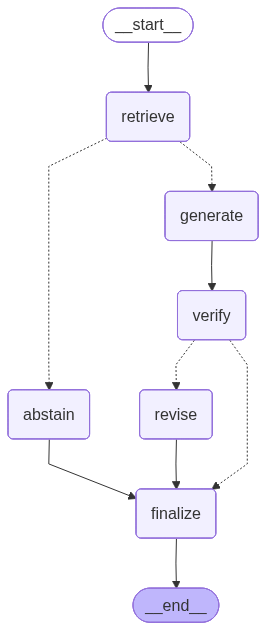

In [9]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

HOW MEMORY WORKS (say this in the demo): MemorySaver checkpoints the full state after every turn, keyed by a thread_id. Same thread_id → the agent sees the whole message history. New thread_id → fresh conversation. The add_messages reducer is what accumulates history instead of overwriting it.

In [10]:
import time
from groq import RateLimitError

def ask(question: str, thread_id: str = "demo", max_retries: int = 3) -> str:
    """Send one question to the agent within a persistent conversation thread.

    Groq's free tier caps tokens-per-minute, which the back-to-back demo
    calls below can hit; retry with a short backoff instead of failing the cell.
    """
    config = {"configurable": {"thread_id": thread_id}}
    for attempt in range(max_retries):
        try:
            result = agent.invoke(
                {"messages": [HumanMessage(content=question)]},
                config=config,
            )
            break
        except RateLimitError:
            wait_s = 15
            print(f"  Rate limit hit, retrying in {wait_s}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_s)
    else:
        raise RuntimeError(f"Failed to get a response after {max_retries} retries")

    answer = result["messages"][-1].content
    verification = result.get("verification", "").upper()
    if verification.startswith("ABSTAINED"):
        badge = f"🚫 Abstained: {result['verification']}"
    elif verification.startswith("VALID"):
        badge = "✅ Verified as grounded in the context"
    else:
        badge = f"🔁 Revised after failing check: {result.get('verification', '')}"

    print(f"🧑 Q: {question}\n")
    print(f"🤖 A: {answer}")
    print(f"\n{badge}")
    print("\n" + "=" * 70)
    return answer

In [11]:
# Example 1 — Regulation (should cite the EU AI Act)
ask("What is considered a high-risk AI system under the EU AI Act?")

2026-07-07 15:53:03,481 [INFO] retrieve: top_score=0.4471 sources=['EU AI Act', 'Ethics Guidelines for Trustworthy AI']


2026-07-07 15:53:03,924 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:04,174 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:04,176 [INFO] verify: VALID


🧑 Q: What is considered a high-risk AI system under the EU AI Act?

🤖 A: According to the EU AI Act, high-risk AI systems include, but are not limited to, those used in healthcare, law enforcement, and critical infrastructure. These systems face stringent requirements to ensure accuracy, transparency, and compliance with ethical standards. The Act does not provide an exhaustive list of high-risk AI systems, but it does mention that deployers of high-risk systems must conduct fundamental rights impact assessments to ensure their AI solutions uphold ethical principles and avoid unintended consequences.

Source: EU AI Act

✅ Verified as grounded in the context



'According to the EU AI Act, high-risk AI systems include, but are not limited to, those used in healthcare, law enforcement, and critical infrastructure. These systems face stringent requirements to ensure accuracy, transparency, and compliance with ethical standards. The Act does not provide an exhaustive list of high-risk AI systems, but it does mention that deployers of high-risk systems must conduct fundamental rights impact assessments to ensure their AI solutions uphold ethical principles and avoid unintended consequences.\n\nSource: EU AI Act'

In [12]:
# Example 2 — Technical foundations (should cite the Bias & Fairness survey)
ask("What are the main types of bias that can appear in machine learning systems?")

2026-07-07 15:53:04,252 [INFO] retrieve: top_score=0.4899 sources=['Bias & Fairness Survey (Mehrabi et al.)', 'EP Study: Ethics of AI', 'EU AI Act']


2026-07-07 15:53:05,296 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:05,743 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:05,744 [INFO] verify: INVALID: The draft introduces new concepts and definitions (e.g., data bias, algorithmic bias, selection bias, confirmation bias, omission bias) that are not present in the provided context, indicating a faithfulness failure.


2026-07-07 15:53:05,807 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:53:05,808 [INFO] Retrying request to /openai/v1/chat/completions in 11.000000 seconds


2026-07-07 15:53:17,178 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


🧑 Q: What are the main types of bias that can appear in machine learning systems?

🤖 A: I don't have enough information in my knowledge base to answer that. However, I can suggest asking a related question, such as "What are some sources of biases that can affect AI applications?" or "How can biases be addressed in AI systems?" This might provide more relevant information from the context.

🔁 Revised after failing check: INVALID: The draft introduces new concepts and definitions (e.g., data bias, algorithmic bias, selection bias, confirmation bias, omission bias) that are not present in the provided context, indicating a faithfulness failure.



'I don\'t have enough information in my knowledge base to answer that. However, I can suggest asking a related question, such as "What are some sources of biases that can affect AI applications?" or "How can biases be addressed in AI systems?" This might provide more relevant information from the context.'

In [13]:
# Example 3 — Ethics principles (should cite the Trustworthy AI Guidelines)
ask("What are the seven key requirements for trustworthy AI in the EU?")

2026-07-07 15:53:17,237 [INFO] retrieve: top_score=0.3906 sources=['EP Study: Ethics of AI', 'Ethics Guidelines for Trustworthy AI']


2026-07-07 15:53:17,296 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:53:17,297 [INFO] Retrying request to /openai/v1/chat/completions in 15.000000 seconds


2026-07-07 15:53:32,790 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:32,867 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:53:32,869 [INFO] Retrying request to /openai/v1/chat/completions in 13.000000 seconds


2026-07-07 15:53:46,191 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:53:46,196 [INFO] verify: VALID


🧑 Q: What are the seven key requirements for trustworthy AI in the EU?

🤖 A: According to the EU's "Ethics Guidelines for Trustworthy AI" and the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", the seven key requirements for trustworthy AI in the EU are:

1. Human agency and oversight
2. Technical robustness and safety
3. Privacy and data governance
4. Transparency
5. Diversity, nondiscrimination, and fairness
6. Societal and environmental wellbeing
7. Accountability

These requirements are outlined in the EU's "Ethics Guidelines for Trustworthy AI" and are considered essential for ensuring that AI systems are trustworthy and beneficial to society.

Source: EU "Ethics Guidelines for Trustworthy AI" and EP Study: Ethics of AI

✅ Verified as grounded in the context



'According to the EU\'s "Ethics Guidelines for Trustworthy AI" and the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", the seven key requirements for trustworthy AI in the EU are:\n\n1. Human agency and oversight\n2. Technical robustness and safety\n3. Privacy and data governance\n4. Transparency\n5. Diversity, nondiscrimination, and fairness\n6. Societal and environmental wellbeing\n7. Accountability\n\nThese requirements are outlined in the EU\'s "Ethics Guidelines for Trustworthy AI" and are considered essential for ensuring that AI systems are trustworthy and beneficial to society.\n\nSource: EU "Ethics Guidelines for Trustworthy AI" and EP Study: Ethics of AI'

In [14]:
# Example 4 — Real-world impact (should cite the EP Ethics study)
ask("What ethical concerns does AI raise in healthcare?")

2026-07-07 15:53:46,277 [INFO] retrieve: top_score=0.3775 sources=['EP Study: Ethics of AI', 'Ethics Guidelines for Trustworthy AI']


2026-07-07 15:53:46,343 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:53:46,345 [INFO] Retrying request to /openai/v1/chat/completions in 17.000000 seconds


2026-07-07 15:54:03,868 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:54:03,927 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:54:03,928 [INFO] Retrying request to /openai/v1/chat/completions in 14.000000 seconds


2026-07-07 15:54:18,456 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:54:18,458 [INFO] verify: VALID


🧑 Q: What ethical concerns does AI raise in healthcare?

🤖 A: According to the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", AI raises several ethical concerns in healthcare, including:

1. Impingement on basic and fundamental human rights, such as human dignity, security, and privacy.
2. Potential to disproportionately affect vulnerable areas of society, such as children, those with disabilities, or the elderly.
3. Risk of reducing quality of life across society.
4. Need to ensure that AI upholds fundamental human rights and prioritizes human well-being.

Additionally, the IEEE recommends that new governance frameworks, standards, and regulatory bodies oversee the use of AI in healthcare to ensure that human rights are protected.

Source: EP Study: Ethics of AI and IEEE Recommendations

✅ Verified as grounded in the context



'According to the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", AI raises several ethical concerns in healthcare, including:\n\n1. Impingement on basic and fundamental human rights, such as human dignity, security, and privacy.\n2. Potential to disproportionately affect vulnerable areas of society, such as children, those with disabilities, or the elderly.\n3. Risk of reducing quality of life across society.\n4. Need to ensure that AI upholds fundamental human rights and prioritizes human well-being.\n\nAdditionally, the IEEE recommends that new governance frameworks, standards, and regulatory bodies oversee the use of AI in healthcare to ensure that human rights are protected.\n\nSource: EP Study: Ethics of AI and IEEE Recommendations'

In [15]:
# Example 5 — OUT-OF-SCOPE test: the agent should say "I don't know" ⭐
ask("What does Japanese AI regulation say about facial recognition?")

2026-07-07 15:54:18,536 [INFO] retrieve: top_score=0.4028 sources=['EP Study: Ethics of AI']


2026-07-07 15:54:18,601 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:54:18,602 [INFO] Retrying request to /openai/v1/chat/completions in 17.000000 seconds


2026-07-07 15:54:36,056 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:54:36,059 [INFO] verify: citation check failed: cites 'EU AI Act' but it was not among the retrieved sources (EP Study: Ethics of AI)


2026-07-07 15:54:36,121 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:54:36,121 [INFO] Retrying request to /openai/v1/chat/completions in 19.000000 seconds


2026-07-07 15:54:55,662 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


🧑 Q: What does Japanese AI regulation say about facial recognition?

🤖 A: I don't have enough information in my knowledge base to answer that. The context provided only includes information about the EU's approach to AI regulation and ethics, as well as some general information about AI applications. It does not mention Japanese AI regulation or facial recognition specifically.

However, you could ask a related question, such as "What does the EU say about facial recognition technology?" or "What are some general concerns about facial recognition technology in AI applications?" This might provide more relevant information from the context.

🔁 Revised after failing check: INVALID: cites 'EU AI Act' but it was not among the retrieved sources (EP Study: Ethics of AI)



'I don\'t have enough information in my knowledge base to answer that. The context provided only includes information about the EU\'s approach to AI regulation and ethics, as well as some general information about AI applications. It does not mention Japanese AI regulation or facial recognition specifically.\n\nHowever, you could ask a related question, such as "What does the EU say about facial recognition technology?" or "What are some general concerns about facial recognition technology in AI applications?" This might provide more relevant information from the context.'

In [16]:
# Turn 1
ask("What is algorithmic bias?", thread_id="memory-demo")

2026-07-07 15:54:55,709 [INFO] retrieve: top_score=0.5734 sources=['Bias & Fairness Survey (Mehrabi et al.)', 'EP Study: Ethics of AI']


2026-07-07 15:54:55,840 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:54:55,842 [INFO] Retrying request to /openai/v1/chat/completions in 11.000000 seconds


2026-07-07 15:55:07,253 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:55:07,312 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:55:07,313 [INFO] Retrying request to /openai/v1/chat/completions in 11.000000 seconds


2026-07-07 15:55:18,587 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:55:18,588 [INFO] verify: VALID


🧑 Q: What is algorithmic bias?

🤖 A: According to the Bias & Fairness Survey (Mehrabi et al.), algorithmic bias is when the bias is not present in the input data and is added purely by the algorithm. This means that the algorithm itself introduces biases, not because of the data it's trained on, but due to its design choices, such as the use of certain optimization functions, regularizations, or statistically biased estimators.

These design choices can lead to biased algorithmic decisions that affect the outcome of the algorithms. For example, the choice of a specific regression model or the way the data is processed can introduce biases that are not present in the original data.

✅ Verified as grounded in the context



"According to the Bias & Fairness Survey (Mehrabi et al.), algorithmic bias is when the bias is not present in the input data and is added purely by the algorithm. This means that the algorithm itself introduces biases, not because of the data it's trained on, but due to its design choices, such as the use of certain optimization functions, regularizations, or statistically biased estimators.\n\nThese design choices can lead to biased algorithmic decisions that affect the outcome of the algorithms. For example, the choice of a specific regression model or the way the data is processed can introduce biases that are not present in the original data."

In [17]:
# Turn 2 — refers to "it" with no other clue: only works if memory works
ask("Can you give me two real-world examples of it?", thread_id="memory-demo")

2026-07-07 15:55:18,664 [INFO] retrieve: top_score=0.5133 sources=['Bias & Fairness Survey (Mehrabi et al.)']


2026-07-07 15:55:18,723 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:55:18,724 [INFO] Retrying request to /openai/v1/chat/completions in 15.000000 seconds


2026-07-07 15:55:34,559 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:55:34,619 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:55:34,620 [INFO] Retrying request to /openai/v1/chat/completions in 15.000000 seconds


2026-07-07 15:55:49,970 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:55:49,973 [INFO] verify: VALID


🧑 Q: Can you give me two real-world examples of it?

🤖 A: According to the Bias & Fairness Survey (Mehrabi et al.), here are two examples of algorithmic bias:

1. **Presentation Bias**: A web search engine that puts specific results at the top of its list. The algorithm's design choice to prioritize certain results over others can lead to biased outcomes, where users are more likely to interact with the top results and ignore the rest. This can perpetuate existing biases in user behavior.
2. **Ranking Bias**: A job recruitment algorithm that ranks candidates based on their resume keywords. If the algorithm is biased towards certain keywords, it may unfairly disadvantage candidates with non-traditional backgrounds or skills. This can lead to biased hiring decisions, where certain groups of people are systematically excluded from job opportunities.

In both cases, the algorithm itself introduces biases that are not present in the input data, leading to unfair outcomes.

✅ Verified as gro

"According to the Bias & Fairness Survey (Mehrabi et al.), here are two examples of algorithmic bias:\n\n1. **Presentation Bias**: A web search engine that puts specific results at the top of its list. The algorithm's design choice to prioritize certain results over others can lead to biased outcomes, where users are more likely to interact with the top results and ignore the rest. This can perpetuate existing biases in user behavior.\n2. **Ranking Bias**: A job recruitment algorithm that ranks candidates based on their resume keywords. If the algorithm is biased towards certain keywords, it may unfairly disadvantage candidates with non-traditional backgrounds or skills. This can lead to biased hiring decisions, where certain groups of people are systematically excluded from job opportunities.\n\nIn both cases, the algorithm itself introduces biases that are not present in the input data, leading to unfair outcomes."

In [18]:
# Turn 3 — refers to the whole previous exchange
ask("Which of those two examples is covered by the EU AI Act?", thread_id="memory-demo")

2026-07-07 15:55:50,056 [INFO] retrieve: top_score=0.5500 sources=['Bias & Fairness Survey (Mehrabi et al.)', 'EP Study: Ethics of AI']


2026-07-07 15:55:50,121 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:55:50,122 [INFO] Retrying request to /openai/v1/chat/completions in 17.000000 seconds


2026-07-07 15:56:07,620 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-07 15:56:07,622 [INFO] verify: citation check failed: cites 'EU AI Act' but it was not among the retrieved sources (Bias & Fairness Survey (Mehrabi et al.), EP Study: Ethics of AI)


2026-07-07 15:56:07,683 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


2026-07-07 15:56:07,684 [INFO] Retrying request to /openai/v1/chat/completions in 18.000000 seconds


2026-07-07 15:56:26,002 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


🧑 Q: Which of those two examples is covered by the EU AI Act?

🤖 A: I don't have enough information in my knowledge base to answer that. The EU AI Act is not mentioned in the provided sources (Bias & Fairness Survey (Mehrabi et al.) and EP Study: Ethics of AI).

🔁 Revised after failing check: INVALID: cites 'EU AI Act' but it was not among the retrieved sources (Bias & Fairness Survey (Mehrabi et al.), EP Study: Ethics of AI)



"I don't have enough information in my knowledge base to answer that. The EU AI Act is not mentioned in the provided sources (Bias & Fairness Survey (Mehrabi et al.) and EP Study: Ethics of AI)."

In [19]:
print("💬 AI Ethics Assistant — type your question ('exit' to quit)\n")

while True:
    try:
        question = input("You: ").strip()
    except Exception:
        # No interactive stdin available (e.g. batch/CI execution, or a
        # headless kernel that raises StdinNotImplementedError instead of
        # EOFError) — stop cleanly rather than crashing the cell.
        print("(no interactive input available — skipping chat loop)")
        break
    if question.lower() in {"exit", "quit", "salir"}:
        print("Goodbye! 👋")
        break
    if question:
        ask(question, thread_id="interactive")

💬 AI Ethics Assistant — type your question ('exit' to quit)

(no interactive input available — skipping chat loop)
